# Notebook 01 — Data Collection
## Semantic Book Recommender | IT4142

**Mục tiêu notebook này:**
- Tải dataset từ Kaggle
- Kiểm tra cấu trúc thô ban đầu (shape, dtypes, missing values)
- Lưu vào `data/raw/books.csv`

> Notebook này **không** thực hiện cleaning hay EDA — đó là việc của notebook 02 và 03.

---

## 0. Cài đặt thư viện

In [15]:
# Chạy cell này một lần duy nhất
!pip install kaggle pandas

## 1. Thiết lập thư mục dự án

In [16]:
import os
import pandas as pd
import zipfile
import warnings
warnings.filterwarnings('ignore')

# Tạo cấu trúc thư mục chuẩn cho toàn bộ project
DIRS = [
    'data/raw',
    'data/processed',
    'data/eval',
    'data/chroma_db',
    'models',
    'notebooks',
    'reports/figures',
    'backend/routers',
    'backend/services',
    'frontend/src',
]

for d in DIRS:
    os.makedirs(f'../{d}', exist_ok=True)

print('Project directory structure created:')
for d in DIRS:
    print(f'  ../{d}/')

Project directory structure created:
  ../data/raw/
  ../data/processed/
  ../data/eval/
  ../data/chroma_db/
  ../models/
  ../notebooks/
  ../reports/figures/
  ../backend/routers/
  ../backend/services/
  ../frontend/src/


## 2. Tải dataset từ Kaggle

### Cách lấy Kaggle API key
1. Truy cập https://www.kaggle.com → Account → Settings
2. Kéo xuống mục **API** → click **Create New Token**
3. File `kaggle.json` sẽ được tải về máy
4. Đặt file vào đúng vị trí:
   - **Windows:** `C:\Users\<username>\.kaggle\kaggle.json`
   - **Linux/Mac:** `~/.kaggle/kaggle.json`
5. Đảm bảo quyền file (Linux/Mac): `chmod 600 ~/.kaggle/kaggle.json`

> Nếu không muốn dùng API, có thể tải thủ công tại:  
> https://www.kaggle.com/datasets/dylanjcastillo/7k-books-with-metadata  
> Sau đó đặt file `.csv` vào thư mục `data/raw/`

In [17]:
RAW_PATH = '../data/raw/books.csv'
DATASET  = 'dylanjcastillo/7k-books-with-metadata'

if os.path.exists(RAW_PATH):
    print(f'Dataset already exists at {RAW_PATH} — skip download.')
else:
    print('Downloading dataset from Kaggle...')
    os.system(f'kaggle datasets download -d {DATASET} -p ../data/raw --unzip')

    # Một số trường hợp file tải về dưới dạng zip, giải nén thủ công
    zip_path = '../data/raw/7k-books-with-metadata.zip'
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall('../data/raw/')
        os.remove(zip_path)
        print('Extracted and removed zip file.')

    print('Download complete.')

Dataset already exists at ../data/raw/books.csv — skip download.


## 3. Load và kiểm tra sơ bộ

In [18]:
df = pd.read_csv(RAW_PATH)

print('=== DATASET OVERVIEW ===')
print(f'Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory     : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print()
df.head(3)

=== DATASET OVERVIEW ===
Shape      : 6,810 rows × 12 columns
Memory     : 6.46 MB



,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0


## 4. Kiểm tra kiểu dữ liệu các cột

In [19]:
print('=== COLUMN TYPES ===')
type_info = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-null count': df.count().values,
    'Null count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2),
    'Sample value': [str(df[col].dropna().iloc[0])[:60] if df[col].notna().any() else 'ALL NULL'
                     for col in df.columns]
})
print(type_info.to_string(index=False))

=== COLUMN TYPES ===
        Column   Dtype  Non-null count  Null count  Null %                                                 Sample value
        isbn13   int64            6810           0    0.00                                                9780002005883
        isbn10     str            6810           0    0.00                                                   0002005883
         title     str            6810           0    0.00                                                       Gilead
      subtitle     str            2381        4429   65.04                                                      A Novel
       authors     str            6738          72    1.06                                           Marilynne Robinson
    categories     str            6711          99    1.45                                                      Fiction
     thumbnail     str            6481         329    4.83 http://books.google.com/books/content?id=KQZCPgAACAAJ&prints
   description     

## 5. Kiểm tra missing values theo cột

=== MISSING VALUES ===
  published_year           6 rows  (  0.09%)  
  average_rating          43 rows  (  0.63%)  
  num_pages               43 rows  (  0.63%)  
  ratings_count           43 rows  (  0.63%)  
  authors                 72 rows  (  1.06%)  
  categories              99 rows  (  1.45%)  
  description            262 rows  (  3.85%)  █
  thumbnail              329 rows  (  4.83%)  ██
  subtitle              4429 rows  ( 65.04%)  ████████████████████████████████


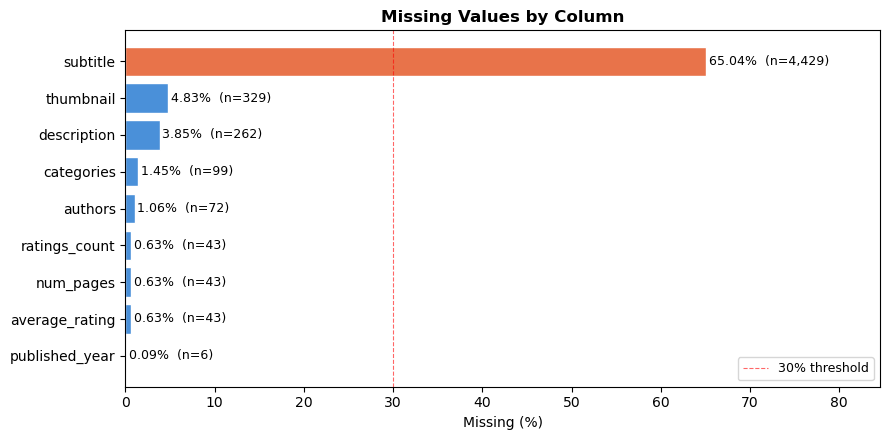

Saved → reports/figures/missing_values.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
missing_pct = (missing / len(df) * 100).round(2)

print('=== MISSING VALUES ===')
for col in missing.index:
    bar = '█' * int(missing_pct[col] / 2)
    print(f'  {col:<20} {missing[col]:>5} rows  ({missing_pct[col]:>6.2f}%)  {bar}')

if len(missing) == 0:
    print('  No missing values found.')

# Plot
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(missing) * 0.5)))
    colors = ['#E8734A' if p > 30 else '#4A90D9' for p in missing_pct]
    bars = ax.barh(missing.index, missing_pct, color=colors, edgecolor='white')
    for bar, pct, cnt in zip(bars, missing_pct, missing):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{pct}%  (n={cnt:,})', va='center', fontsize=9)
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values by Column', fontweight='bold', fontsize=12)
    ax.set_xlim(0, missing_pct.max() * 1.3)
    ax.axvline(x=30, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='30% threshold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('../reports/figures/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/figures/missing_values.png')

## 6. Kiểm tra duplicate

In [21]:
dup_all   = df.duplicated().sum()
dup_isbn  = df.duplicated(subset='isbn13').sum() if 'isbn13' in df.columns else 'N/A'
dup_title = df.duplicated(subset='title').sum()  if 'title'  in df.columns else 'N/A'

print('=== DUPLICATE CHECK ===')
print(f'  Full-row duplicates    : {dup_all}')
print(f'  Duplicate isbn13       : {dup_isbn}')
print(f'  Duplicate title        : {dup_title}')

if dup_isbn and dup_isbn > 0:
    print()
    print('Sample duplicate isbn13 entries:')
    dup_mask = df.duplicated(subset='isbn13', keep=False)
    print(df[dup_mask][['isbn13', 'title', 'authors']].head(6).to_string(index=False))

=== DUPLICATE CHECK ===
  Full-row duplicates    : 0
  Duplicate isbn13       : 0
  Duplicate title        : 412


## 7. Kiểm tra nhanh cột `description` — cột quan trọng nhất

=== DESCRIPTION COLUMN STATS ===
  Non-null count     : 6,548 / 6,810
  Empty string count : 0
  Word count — min   : 1
  Word count — max   : 920
  Word count — mean  : 66.7
  Word count — median: 40.0



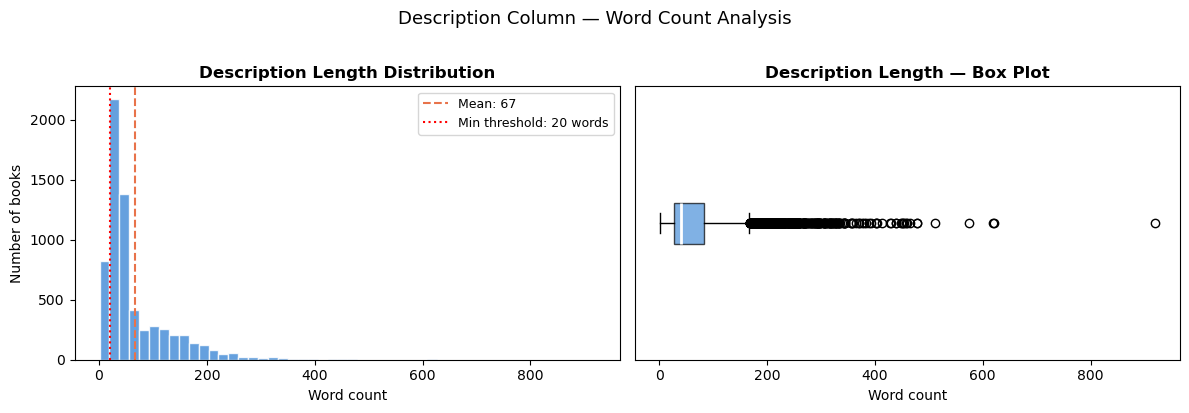

Saved → reports/figures/description_length_raw.png

  Descriptions with < 20 words: 819 (will be filtered in preprocessing)


In [22]:
desc = df['description'].dropna()
desc_len = desc.str.split().str.len()

print('=== DESCRIPTION COLUMN STATS ===')
print(f'  Non-null count     : {len(desc):,} / {len(df):,}')
print(f'  Empty string count : {(desc.str.strip() == "").sum()}')
print(f'  Word count — min   : {desc_len.min()}')
print(f'  Word count — max   : {desc_len.max()}')
print(f'  Word count — mean  : {desc_len.mean():.1f}')
print(f'  Word count — median: {desc_len.median():.1f}')
print()

# Phân phối độ dài description
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(desc_len, bins=50, color='#4A90D9', edgecolor='white', alpha=0.85)
axes[0].axvline(desc_len.mean(), color='#E8734A', linestyle='--', linewidth=1.5, label=f'Mean: {desc_len.mean():.0f}')
axes[0].axvline(20, color='red', linestyle=':', linewidth=1.5, label='Min threshold: 20 words')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Number of books')
axes[0].set_title('Description Length Distribution', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].boxplot(desc_len, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#4A90D9', alpha=0.7),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_xlabel('Word count')
axes[1].set_title('Description Length — Box Plot', fontweight='bold')
axes[1].set_yticks([])

plt.suptitle('Description Column — Word Count Analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/description_length_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/figures/description_length_raw.png')

too_short = (desc_len < 20).sum()
print(f'\n  Descriptions with < 20 words: {too_short} (will be filtered in preprocessing)')

## 8. Kiểm tra nhanh các cột số

In [23]:
numeric_cols = ['average_rating', 'num_pages', 'ratings_count', 'published_year']
existing_num = [c for c in numeric_cols if c in df.columns]

print('=== NUMERIC COLUMNS — DESCRIBE ===')
print(df[existing_num].describe().round(2).to_string())

# Quick range check
print()
checks = {
    'average_rating':  (1.0, 5.0),
    'published_year':  (1800, 2024),
    'num_pages':       (10, 1500),
    'ratings_count':   (0, None),
}
print('Range violations (values outside expected bounds):')
for col, (lo, hi) in checks.items():
    if col not in df.columns:
        continue
    s = df[col].dropna()
    below = (s < lo).sum() if lo is not None else 0
    above = (s > hi).sum() if hi is not None else 0
    flag = '⚠' if (below + above) > 0 else '✓'
    print(f'  {flag} {col:<20} below {lo}: {below:>4}   above {hi}: {above:>4}')

=== NUMERIC COLUMNS — DESCRIBE ===
       average_rating  num_pages  ratings_count  published_year
count         6767.00    6767.00        6767.00         6804.00
mean             3.93     348.18       21069.10         1998.63
std              0.33     242.38      137620.68           10.48
min              0.00       0.00           0.00         1853.00
25%              3.77     208.00         159.00         1996.00
50%              3.96     304.00        1018.00         2002.00
75%              4.13     420.00        5992.50         2005.00
max              5.00    3342.00     5629932.00         2019.00

Range violations (values outside expected bounds):
  ⚠ average_rating       below 1.0:   10   above 5.0:    0
  ✓ published_year       below 1800:    0   above 2024:    0
  ⚠ num_pages            below 10:    7   above 1500:   26
  ✓ ratings_count        below 0:    0   above None:    0


## 9. Kiểm tra nhanh cột `categories`

Total unique categories: 567
Most common categories:
categories
Fiction                      2588
Juvenile Fiction              538
Biography & Autobiography     401
History                       264
Literary Criticism            166
Philosophy                    160
Comics & Graphic Novels       159
Religion                      137
Drama                         132
Juvenile Nonfiction           116
Poetry                         79
Literary Collections           71
Science                        71
Business & Economics           67
Social Science                 60
Performing Arts                50
Cooking                        47
Art                            46
Body, Mind & Spirit            44
Psychology                     43


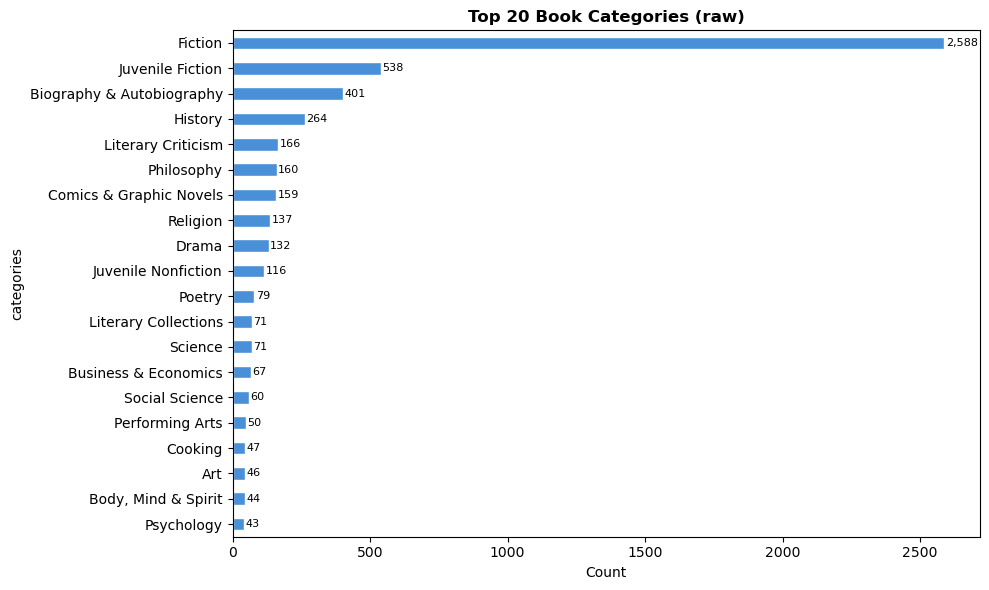

Saved → reports/figures/top_categories_raw.png


In [24]:
if 'categories' in df.columns:
    cats = df['categories'].dropna()
    top_cats = cats.value_counts().head(20)
    print(f'Total unique categories: {cats.nunique():,}')
    print(f'Most common categories:')
    print(top_cats.to_string())

    fig, ax = plt.subplots(figsize=(10, 6))
    top_cats.sort_values().plot(kind='barh', ax=ax, color='#4A90D9', edgecolor='white')
    ax.set_title('Top 20 Book Categories (raw)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Count')
    for bar in ax.patches:
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f'{int(bar.get_width()):,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('../reports/figures/top_categories_raw.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/figures/top_categories_raw.png')

## 10. Tổng kết — Raw Dataset Health Report

In [25]:
print('=' * 55)
print('   RAW DATASET HEALTH REPORT')
print('=' * 55)
print(f'  Total records         : {len(df):,}')
print(f'  Total columns         : {df.shape[1]}')
print()
print('  KEY COLUMN STATUS:')

key_cols = {
    'description':   'Core NLP input — embedding + retrieval',
    'categories':    'Ground truth proxy for evaluation',
    'thumbnail':     'Book cover image URL',
    'average_rating':'Display + ranking',
    'title':         'Display',
    'authors':       'Display',
}

for col, purpose in key_cols.items():
    if col in df.columns:
        null_pct = df[col].isnull().mean() * 100
        status = '✓ OK' if null_pct < 5 else ('⚠ HIGH MISSING' if null_pct > 30 else '~ MODERATE')
        print(f'  {status:<15} {col:<18} missing={null_pct:.1f}%  | {purpose}')
    else:
        print(f'  ✗ NOT FOUND    {col}')

desc_missing = df['description'].isnull().sum()
est_clean = len(df) - desc_missing
print()
print(f'  Estimated rows after dropping null description: ~{est_clean:,}')
print()
print('  NEXT STEP → Run 02_eda_visualization.ipynb')
print('=' * 55)

   RAW DATASET HEALTH REPORT
  Total records         : 6,810
  Total columns         : 12

  KEY COLUMN STATUS:
  ✓ OK            description        missing=3.8%  | Core NLP input — embedding + retrieval
  ✓ OK            categories         missing=1.5%  | Ground truth proxy for evaluation
  ✓ OK            thumbnail          missing=4.8%  | Book cover image URL
  ✓ OK            average_rating     missing=0.6%  | Display + ranking
  ✓ OK            title              missing=0.0%  | Display
  ✓ OK            authors            missing=1.1%  | Display

  Estimated rows after dropping null description: ~6,548

  NEXT STEP → Run 02_eda_visualization.ipynb


## 11. Lưu raw dataset (xác nhận vị trí)

> Notebook này **không thay đổi** dữ liệu gốc.  
> Chỉ xác nhận file tồn tại đúng vị trí để các notebook sau đọc.

In [26]:
assert os.path.exists(RAW_PATH), f'ERROR: Raw file not found at {RAW_PATH}'

file_size = os.path.getsize(RAW_PATH) / 1024
print(f'Raw dataset confirmed at: {RAW_PATH}')
print(f'File size              : {file_size:.1f} KB')
print(f'Rows                   : {len(df):,}')
print(f'Columns                : {list(df.columns)}')
print()
print('Notebook 01 complete. Proceed to 02_eda_visualization.ipynb')

Raw dataset confirmed at: ../data/raw/books.csv
File size              : 4045.1 KB
Rows                   : 6,810
Columns                : ['isbn13', 'isbn10', 'title', 'subtitle', 'authors', 'categories', 'thumbnail', 'description', 'published_year', 'average_rating', 'num_pages', 'ratings_count']

Notebook 01 complete. Proceed to 02_eda_visualization.ipynb
